# Questão 2. Regressão Polinomial

Suponha que $m \geq d+1$. Defina a função $R_{X,d} : \mathbb R^m \to \mathcal P_d$ que associa a cada vetor $b \in \mathbb R^m$ o polinômio $p \in \mathcal P_d$ que melhor se ajusta aos valores $b_i$ (nos pontos $x_i \in X$) no sentido de mínimos quadrados, ou seja, $\argmin_{p \in \mathcal P_d}\left\|L_X(p) - b\right\|_2^2$.


## Letra (a):

Mostre que $R_{X,d}$ é uma inversa à esquerda de $L_X$, ou seja, $R_{X,d}\circ L_X = \text{id}_{\mathcal P_d}$.

Note que $(R_{X,d}\circ L_X)(p) = R_{X,d}(L_X(p)) = \argmin_{q \in \mathcal P_d}\left\|L_X(q) - L_X(p)\right\|_2^2 = \argmin_{q \in \mathcal P_d}\left\|L_X(q - p)\right\|_2^2$. Analisando a função $\left\|L_X(q - p)\right\|_2^2$, como $L_X$ é uma transformação linear (questão 1), $L_X(0) = 0$. Portanto, $q = p$ minimiza a função $\left\|L_X(q - p)\right\|_2^2$, o que implica em 
$$R_{X_d}(L_X(p)) = p.$$

## Letra (b):

Se convença que $R_{X,d}$ é uma transformação linear.

In [16]:
using LinearAlgebra

function R_Xd_manual(X, d, b)
    m = length(X)
    V = zeros(m, d+1)
    for i in 1:m
        for j in 0:d
            V[i, j+1] = X[i]^j
        end
    end
    c = V \ b   # resolve min ||Vc - b||_2
    return c
    # return x -> sum(c[j+1] * x^j for j in 0:d)
end

function teste_linearidade()

    println("#=== Variando o grau dos polinômios ===#")
    println("# teste R_Xd(a + b) = R_Xd(a) + R_Xd(b):")
    for d in 5:10
        println("# Teste com polinômios de grau $d")
        x = rand(1:10, (d + 2))
        a = rand(1:10, (d + 2))
        b = rand(1:10, (d + 2))
        
        r1 = R_Xd_manual(x, d, a)
        r2 = R_Xd_manual(x, d, b)
        r3 = R_Xd_manual(x, d, (a + b))

        if (norm((r3 - r2 - r1)) < 1e-10)
            println("True")
        else
            println("False")
        end

    end

    println("\n\n#=== teste R_Xd(ka) = k R_Xd(a) ===#")
    for d in 5:10
        println("# Teste com polinômios de grau $d")
        x = rand(1:10, (d + 2))
        a = rand(1:10, (d + 2))
        c = rand(1:10)
        
        r1 = R_Xd_manual(x, d, a)
        r2 = R_Xd_manual(x, d, (c*a))
        
        if (norm((r2 - c * r1)) < 1e-10)
            println("True")
        else
            println("False")
        end

    end

    println("\n#=== Variando o total de pontos ===#\n")
    for pts in 10:15
        println("# Teste com $pts pontos")
        x = rand(1:10, pts)
        a = rand(1:10, pts)
        b = rand(1:10, pts)
        a1 = rand(1:10)
        b1 = rand(1:10)

        r1 = R_Xd_manual(x, 8, a)
        r2 = R_Xd_manual(x, 8, b)
        r3 = R_Xd_manual(x, 8, (a1 * a + b1 * b))

        if(norm((r3 - a1 * r1 - b1 * r2)) < 1e-10)
            println("True")
        else
            println("False")
        end

    end
end

teste_linearidade()


#=== Variando o grau dos polinômios ===#
# teste R_Xd(a + b) = R_Xd(a) + R_Xd(b):
# Teste com polinômios de grau 5
True
# Teste com polinômios de grau 6
True
# Teste com polinômios de grau 7
True
# Teste com polinômios de grau 8
True
# Teste com polinômios de grau 9
True
# Teste com polinômios de grau 10
True


#=== teste R_Xd(ka) = k R_Xd(a) ===#
# Teste com polinômios de grau 5
True
# Teste com polinômios de grau 6
True
# Teste com polinômios de grau 7
True
# Teste com polinômios de grau 8
True
# Teste com polinômios de grau 9
True
# Teste com polinômios de grau 10
True

#=== Variando o total de pontos ===#

# Teste com 10 pontos
True
# Teste com 11 pontos
True
# Teste com 12 pontos
True
# Teste com 13 pontos
True
# Teste com 14 pontos
True
# Teste com 15 pontos
True


Acima, testamos se $R_{X,d}$ satisfaz as propriedades de uma transformação linear para diversas instâncias de $X$ e $d$ ($R_{X,d}(0) = 0$ é trivial). Para implementar $R_{X,d}$, utilizamos da função solve ('\\') em julia que resolve o problema de mínimos quadrados, e escrevemos $L_X(p) = Vc$, onde $V$ é a matriz de Vandermonde de $X$, que representa $L_X$ quando $p$ está sendo representado por um vetor na base canônica de $\mathcal P_d$, no caso, o vetor $c$ (vetor $d+1$-dimensional de coeficientes de $p$), como foi visto na questão 1.

## Letra (c):

Como calcular a matrix de $R_{X, d}$ na base canônica de $\mathcal P_d$?

A base canônica de $\mathcal P_d$ é dada por $\left\{1, x, x^2,\dots, x^d\right\}$. Como visto anteriormente e na questão 1, 
$$L_X(p) = Vc, \text{ onde } V = \begin{bmatrix} 1 & x_1 & \cdots & x_1^d \\ 1 & x_2 & \cdots & x_2^d \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_m & \cdots & x_m^d\end{bmatrix},$$

e $c = \begin{bmatrix} c_0 & c_1 & \cdots & c_d\end{bmatrix}^T$ é o vetor de coeficientes de $p$. Logo, temos que 
$$R_{X,d}(b)= \argmin_{c \in \mathbb R^{d+1}}\left\|Vc - b\right\|_2^2.$$

Para minimizar $\left\|Vc - b\right\|_2^2$, o vetor $Vc - b$ deve ser ortogonal ao espaço coluna de $V$. Isso nos leva a

$$V^T(Vc - b) = 0 \Rightarrow V^TVc = V^Tb.$$
Como $V$ tem posto completo (questão 1 letra (d)), sabemos que $V^TV$ é simétrica e positiva definida. De fato, note que 
$$x^T(V^TV)x = \left<Vx, Vx\right> = \left\|Vx\right\|_2^2 = 0 \iff Vx = 0 \iff x = 0.$$
Logo, $V^TV$ é invertível, e temos que
$$c = (V^TV)^{-1}V^Tb,$$
isto é, $R_{X,d} = (V^TV)^{-1}V^T$.


## Letra (d):

$\textbf{Condicionamento.}$ Escolha alguns valores de $m$ e $d$ e calcule os números de condicionamento das matrizes $L_X$ e $R_{X,d}$ na base canônica de $\mathcal P_d$. Como o número de condicionamento das matrizes $L_X$ e $R_{X,d}$ se comporta conforme $m$ e/ou $d$ aumentam?

Lema: O condicionamento da matriz de $R_{X,d}$ é igual ao condicionamento da matriz de $L_{X}$

$L_{X}$ na base canônica de $\mathcal P_d$ é a matriz $V$ de vandermonde, onde $V_{ij} = x_{i}^{j-1}$. Também,
$R_{X,d}$ é a pseudo-inversa da matriz de $L_{X}$, ou seja, $(V^{T}V)^{-1}V^{T} = V^\dagger$. Seja $s_{1}, \dots, s_{n}$
os valores singulares de $V$, com $s_{1} \geq s_{2} \geq \dots \geq s_{n}$. Então existem listas ortonormais $e_{1}, \dots, e_{n}$ e $f_{1}, \dots, f_{n}$
tais que:
$$Vu = s_{1}\left\langle u, e_{1} \right\rangle f_{1} + ... + s_{n} \left\langle u, e_{n} \right\rangle f_{n}$$
e
$$V^\dagger u = \frac{\left\langle u, f_{1} \right\rangle}{s_{1}} e_{1} + ... + \frac{\left\langle u, f_{n} \right\rangle}{s_{n}} e_{n}$$

Sabemos que o condicionamento de uma matriz é o maior valor singular dividido pelo menor. Então
$$\kappa(V) = \frac{s_{1}}{s_{n}}$$
Enquanto isso, o maior valor singular de $V^\dagger$ é $\frac{1}{s_{n}}$, enquanto o menor é $\frac{1}{s_{1}}$. Logo,
$$\kappa(V^\dagger) = \frac{\frac{1}{s_{n}}} {\frac{1}{s_{1}}} = \frac{s_{1}}{s_{n}} = \kappa(V).$$

Logo, os condicionamentos são iguais
Desse modo, basta analisar o comportamento do condicionamento da matriz de $L_{X}$ quando $d$ e $m$ variam, 
pois este será igual ao da matriz de $R_{X,d}$.


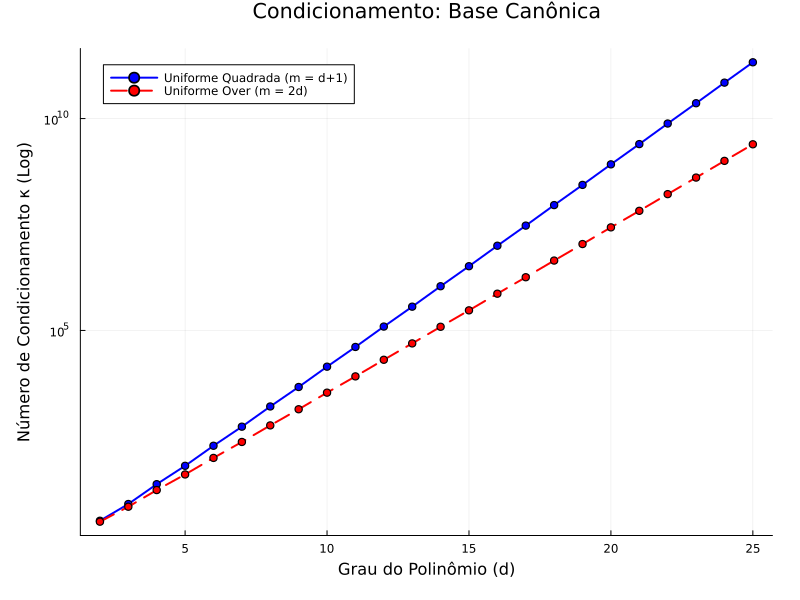

In [17]:
using Plots

function matrix_vandermonde(X, d)
    m = length(X)
    V = zeros(Float64, m, d+1)
    for i in 1:m
        for j in 1:d+1
            V[i, j] = X[i]^(j-1)
        end
    end
    return V
end

function plot_conditioning_canonical(d_max=25)
    degrees = 2:d_max
    
    cond_uni_exact  = Float64[]
    cond_uni_over   = Float64[]
    
    for d in degrees
        push!(cond_uni_exact,  cond(matrix_vandermonde(range(-1.0, 1.0, length=d+1), d)))
        m_over = 2 * d
        push!(cond_uni_over,   cond(matrix_vandermonde(range(-1.0, 1.0, length=m_over), d)))
    end
    
    p = plot(title="Condicionamento: Base Canônica",
             xlabel="Grau do Polinômio (d)", 
             ylabel="Número de Condicionamento κ (Log)",
             yscale=:log10, 
             legend=:topleft,
             grid=true,
             size=(800, 600),
             margin=5Plots.mm)
             
    plot!(p, degrees, cond_uni_exact,  label="Uniforme Quadrada (m = d+1)", lw=2, marker=:circle, color=:blue)
    plot!(p, degrees, cond_uni_over,   label="Uniforme Over (m = 2d)", lw=2, ls=:dash, marker=:circle, color=:red)

    return p
end

plot_conditioning_canonical()

## Letra (e)

Calcule as matrizes de $L_X$ e $R_{X,d}$ usando a base dos polinômios interpoladores de Lagrange. Qual o condicionamento das matrizes $L_X$ e $R_{X,d}$ nestas bases?

As colunas das matrizes correspondem a aplicação das transformações nos vetores base. Isto é, $L_X = \begin{bmatrix} L_X^1 & L_X^2 & \cdots & L_X^{d+1}\end{bmatrix}$, onde
$$L_X^j = L_X(p_j) = \begin{bmatrix} p_j(x_1) \\ \vdots \\ p_j(x_{d+1}) \\ p_j(x_{d+2}) \\ \vdots \\ p_j(x_m) \end{bmatrix} = \begin{bmatrix} \delta_{1j} \\ \vdots \\ \delta_{(d+1)j} \\ p_j(x_{d+2}) \\ \vdots \\ p_j(x_m)\end{bmatrix}.$$

Logo, se $\ell = \left\{p_1,p_2,\dots,p_{d+1}\right\}$ é a base de dos polinômios interpoladores de Lagrange, temos que 
$$M_L := [L_X]_\ell = \begin{bmatrix} I_{d+1} \\ P\end{bmatrix},$$
onde $P$ é a matriz $(m- d - 1)\times (d+1)$ com as avaliações dos polinômios nos pontos "extras".

Como $R_{X,d}$ é a pseudo-inversa de $L_X$ (letra (c)), temos que a matriz $R_{X,d}$ na base de Lagrange é
$$T := [R_{X,d}]_\ell = (M_L^TM_L)^{-1}M_L^T.$$

Note que
$$M_L^TM = \begin{bmatrix} I_{d+1} & P^T\end{bmatrix}\begin{bmatrix} I_{d+1} \\ P\end{bmatrix} = I_{d+1} + P^TP.$$

Assim,
$$T = (I_{d+1} + P^TP)^{-1}\begin{bmatrix} I_{d+1} & P^T\end{bmatrix}.$$

Para analisar o condicionamento das matrizes nestas bases, basta observar o condicionamento de $M_L$, pois $\kappa(M_L) = \kappa(T)$ (letra (d)).

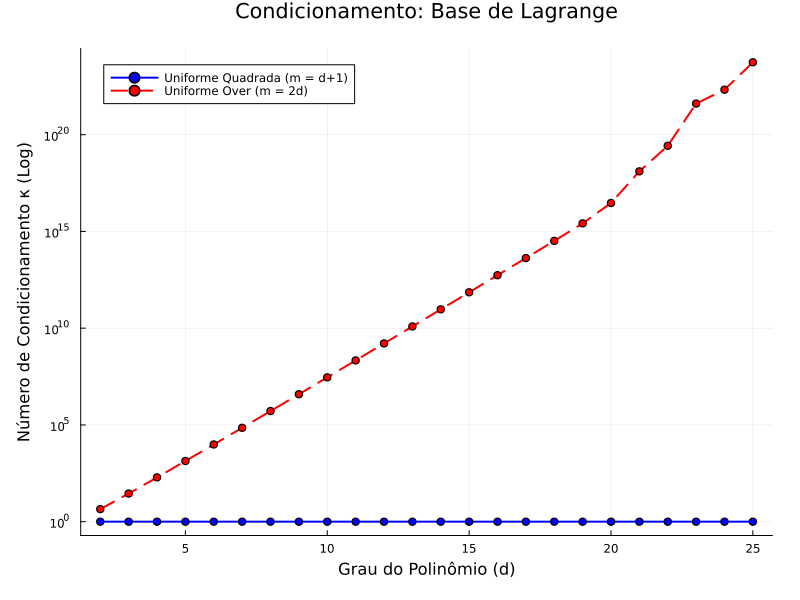

In [18]:
function denominator_lagrange(X, j, d)
    val = 1.0
    for k in 1:d+1
        if k != j
            val *= X[j] - X[k]
        end
    end
    return 1 / val
end

function lagrange_base_eval(X, x, j, d, D)
    val = D 
    for k in 1:d+1
        if k != j
            val *= (x - X[k])
        end
    end
    return val
end

function matrix_lagrange(X, d)
    m = length(X)
    M_L = zeros(Float64, m, d + 1)
    
    for i in 1:(d + 1)
        M_L[i, i] = 1.0
    end

    if m == d + 1
        return M_L
    end

    X_base = @view X[1:d+1]

    for j in 1:(d + 1)
        D = denominator_lagrange(X_base, j, d)
        for i in (d+2):m
            M_L[i, j] = lagrange_base_eval(X_base, X[i], j, d, D)
        end
    end

    return M_L
end


function plot_conditioning(d_max=25)
    degrees = 2:d_max
    
    cond_uni_exact  = Float64[]
    cond_uni_over   = Float64[]
    
    for d in degrees
        push!(cond_uni_exact,  cond(matrix_lagrange(range(-1.0, 1.0, length=d+1), d)))
        m_over = 2 * d
        push!(cond_uni_over,   cond(matrix_lagrange(range(-1.0, 1.0, length=m_over), d)))
    end
    
    p = plot(title="Condicionamento: Base de Lagrange",
             xlabel="Grau do Polinômio (d)", 
             ylabel="Número de Condicionamento κ (Log)",
             yscale=:log10, 
             legend=:topleft,
             grid=true,
             size=(800, 600),
             margin=5Plots.mm)
             
    plot!(p, degrees, cond_uni_exact,  label="Uniforme Quadrada (m = d+1)", lw=2, marker=:circle, color=:blue)
    plot!(p, degrees, cond_uni_over,   label="Uniforme Over (m = 2d)", lw=2, ls=:dash, marker=:circle, color=:red)
    
    return p
end

plot_conditioning(25)



## Letra (f):

Compare a complexidade computacional de calcular $L_X$ e $R_{X,d}$ usando as bases canônica e de Lagrange com o condicionamento das matrizes.

### Complexidade na Base Canônica:
#### $L_X$
A complexidade para se calcular a matriz $V$ de $L_{X}$ é $O(md)$, pois, dado o conjunto $X = \left\{x_{1}, ..., x_{m}\right\}$
de pontos, calculamos as $m(d + 1)$ entradas da matriz, cada uma com custo $O(1)$ pois $V_{ij} = x_{i}^{j - 1}$ é
uma exponenciação de custo $O(1)$.

#### $R_{X, d}$
Para a matriz $V^\dagger$ de $R^{X, d}$, a complexidade é $min\{O(md^2), O(m^2d)\} = O(md^2)$ e pode ser computada de por algoritmos estáveis de $QR$ e $SVD$. Porém, em muitas aplicações não é necessário calcular a pseudoinversa diretamente. Quando você quer calcular os coeficientes do polinômio que melhor se ajustam a um conjunto de valores, usar simplesmente $c = V \backslash b$ é muito melhor! 

Para calcular o condicionamento de $V^\dagger$ também não é necessário computá-la diretamente. Como provado, seu condicionamento é igual ao de $V$. Por isso, basta calcular $k(V)$, muito menos custoso e muito mais preciso do que fazer $(V^TV)^{-1}V^T$ e só então achar $k(V^\dagger)$


### Complexidade na Base de Lagrange:
#### $L_{X}$: Caso específico
O custo computacional para calcular a matriz de $L_{X}$ na base de lagrange é $O(d^{2}m)$. A $j$-ésima coluna da matriz $L$
de $L_{X}$ é $L_{X}(p_{j})$, $L_{X}$ aplicado no $j$-ésimo polinômio da base de lagrange. Quando usamos uma base conveninte em que $p_{j}(x_{i}) = \delta_{ij}$ para
$1 \leq i \leq d + 1, 1 \leq j \leq d + 1$, então o bloco $(d + 1) \times (d + 1)$ superior de $L$ será a identidade. Se $m = d + 1$, então
$L$ é simplesmente a identidade (e $R_{X, d}$ também será!), um resultado muito bonito pois o condicionamento será 1,
o condicionamento perfeito. Porém, quando $m > d + 1$, teremos um bloco $(m - d - 1) \times (d + 1)$ de valores que a priore
não temos muitas informações. O que sabemos é que $L_{ij} = p_{j}(x_{i})$ para $m \geq i \geq d + 2$.

Para colocar as $d + 1$ entradas 1 na diagonal do bloco identidade, são necessárias $d + 1$ operações. Se m = (d + 1), $L$ é simplesmente a identidade e a complexidade é $d + 1 = O(d)$.
Para calcular as demais entradas quando $m > d + 1$, seguimos o seguinte algoritmo:
Analisamos coluna por coluna. O polinômio de lagrange é $$p_{j}(x) = \prod_{i \neq j}^{d + 1}\frac{x-x_{i}}{x_{j} - x_{i}}.$$
Vamos calcular apenas uma vez o denominador. São $d$ subtrações e $d - 1$ multiplicações. Ou seja, $2d - 1$ operações para
calcular o denominador. Para a i-ésima entrada da coluna, devemos calcular $\prod_{k \neq j}^{d + 1} x_i-x_k$
e depois dividir pelo denominador já calculado. No numerador fazemos $2d - 1$ operações, e com a divisão vamos para $2d$ operações. Logo, para cada coluna fazemos $(2d - 1) + (m - d - 1)(2d)$ operações. Como são $d + 1$ colunas, são necessárias
$$\left[(2d - 1) + (m - d - 1)(2d)\right](d + 1) = 2d^{2}m - 2d^{3} - d + 2dm - 2d^{2} - 1 \text{ operações.}$$
 Somado com as $d + 1$ da identidade
obtemos $2d^{2}m - 2d^{3} + 2dm - 2d^{2}$. 
#### $L_X$: Caso geral
Nem sempre estaremos trabalhando com tal base de Lagrange. Suponha $X = (x_{1}, ..., x_{m})$ e temos a base $p_j(y_i) = \delta _{ji}, \forall y_i \in Y = (y_1, ..., y_{d+1})$. Agora, não temos informações sobre $p_j(x_i)$. Por isso, o processo que fizemos para as últimas $m - d - 1$ linhas anteriormente, será aplicado para todas as linhas. A i-ésima coluna de $L$ será $L_X(p_i)$. Para a i-ésima coluna, calculamos o denominador $\prod_{i \neq j}^{d + 1} y_j-y_i$, que são $2d -1$ operações. Para a j-ésima entrada da coluna, calculamos $\prod_{k \neq i}^{d + 1} x_j-y_{k}$ e dividimos pelo denominador, dando $2d$ operações. Logo, em cada coluna fazemos $2d - 1 + (2d)m = 2dm + 2d - 1$. Como são $d + 1$ colunas, no total fazemos $$(2dm + 2d - 1)(d + 1) = 2d^2m + 2d^2 - d - 1 + 2dm + 2d - 1 = 2md^2 + 2d^2 + 2dm + d -2$$ Operações
#### $R_{X, d}$
Quando m = (d + 1), $L$ é a identidade, e, portanto, $L^\dagger$ também será a identidade. Portanto, um custo $O(d)$ para computá-la. Para m > d + 1, o cálculo da pseudo-inversa será $O(md^2)$ pois, infelizmente, a base de Lagrange não facilita o cálculo de $L^\dagger$. 

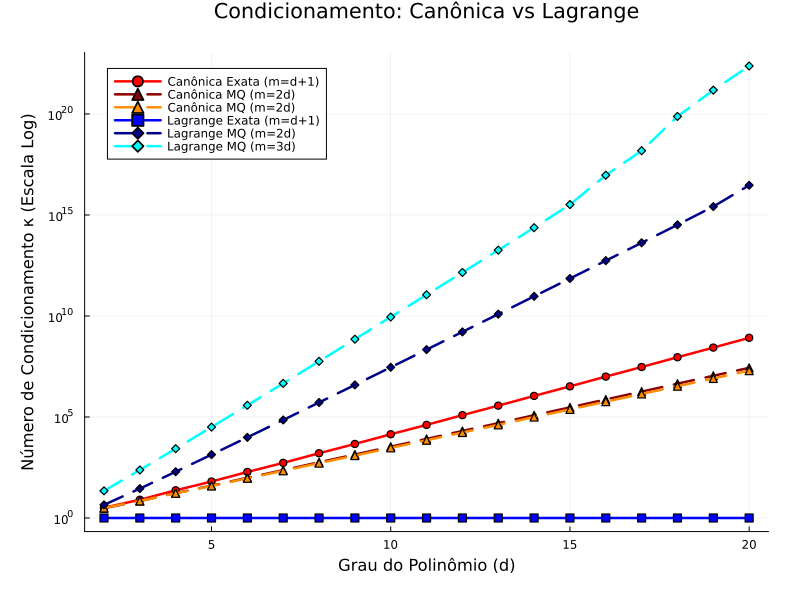

In [19]:
function plot_comparison_bases(d_max=20)
    degrees = 2:d_max
    
    cond_can_exato = Float64[]
    cond_can_2d   = Float64[]
    cond_can_3d = Float64[]

    cond_lag_exato = Float64[]
    cond_lag_2d    = Float64[]
    cond_lag_3d    = Float64[]
    
    for d in degrees
        X_exato = range(-1.0, 1.0, length=d+1)
        X_2d   = range(-1.0, 1.0, length=2d)
        X_3d   = range(-1.0, 1.0, length=3d)
        
        push!(cond_can_exato, cond(matrix_vandermonde(X_exato, d)))
        push!(cond_can_2d,    cond(matrix_vandermonde(X_2d, d)))
        push!(cond_can_3d,    cond(matrix_vandermonde(X_3d, d)))       
        
        push!(cond_lag_exato, cond(matrix_lagrange(X_exato, d)))
        push!(cond_lag_2d,    cond(matrix_lagrange(X_2d, d)))
        push!(cond_lag_3d,    cond(matrix_lagrange(X_3d, d)))

    end
    
    p = plot(title="Condicionamento: Canônica vs Lagrange",
             xlabel="Grau do Polinômio (d)",
             ylabel="Número de Condicionamento κ (Escala Log)",
             yscale=:log10, 
             legend=:topleft,
             grid=true,
             size=(800, 600),
             margin=6Plots.mm)
             
    plot!(p, degrees, cond_can_exato, label="Canônica Exata (m=d+1)", lw=2.5, color=:red, marker=:circle)
    plot!(p, degrees, cond_can_2d,    label="Canônica MQ (m=2d)", lw=2.5, color=:darkred, ls=:dash, marker=:utriangle)
    plot!(p, degrees, cond_can_3d,    label="Canônica MQ (m=2d)", lw=2.5, color=:darkorange, ls=:dash, marker=:utriangle)
    
    plot!(p, degrees, cond_lag_exato, label="Lagrange Exata (m=d+1)", lw=2.5, color=:blue, marker=:square)
    plot!(p, degrees, cond_lag_2d,    label="Lagrange MQ (m=2d)", lw=2.5, color=:darkblue, ls=:dash, marker=:diamond)
    plot!(p, degrees, cond_lag_3d,    label="Lagrange MQ (m=3d)", lw=2.5, color=:cyan, ls=:dash, marker=:diamond)
    
    return p
end

plot_comparison_bases(20)

Ou seja, quando $m = d+1$, utilizar a matriz na base de Lagrange é muito mais eficiente, pois precisamos de apenas $\approx d+1$ operações para construir a matriz identidade, e ela possui condicionamento 1, enquanto calcular $L_X$ na base canônica continua sendo $O(md)$ e o condicionamento cresce exponencialmente com $d$. Entretanto, percebe-se que quando $m > d+1$, o condicionamento da matriz de base Lagrange cresce mais rápido em função de $d$.

# Questão 3. Interpolação e Extrapolação

## Letra (a):

Qual o posto da aplicação composta $L_Y\circ R_{X,d}$?

Como foi visto na questão 2 letra (a), $(R_{X,d}\circ L_X)(p) = p$, para todo $p \in \mathcal P_d$. Logo, $R_{X,d}$ é sobrejetora (gera todo o espaço $\mathcal P_d$), o que implica que o posto de $L_Y \circ R_{X,d}$ é simplesmente o posto de $L_Y:\mathcal P_d \to \mathbb R^n$. Como foi visto na letra (d) da questão 1, $\text{rank}(L_Y) = \min\left\{n, d+1\right\}$.

### Letra b)

Por que a matriz não depende da base? A aplicação recebe um conjunto de pontos $b = (b_{1}, ..., b_{m})$, calcula, através de $R_{X, d}$, o polinômio $p$ de grau d que melhor se ajusta aos pontos de $b$. Depois, através de $L_{Y}$, avalia $p$ nos pontos $Y = (y_{1}, ..., y_{n})$, retornando $(p(y_{1}), ..., p(y_{n}))$. Como $p(x)$ tem o mesmo valor independente da base em que $p$ está representado, tanto a entrada quanto a saída de $L_{Y} \circ R_{X, d}$ serão a mesma, qualquer seja a base utilizada. O polinômio é "engolido" dentro da aplicação, ele serve apenas de passo intermediário e tem a mesma saída seja qual for a forma como está representado.

Matematicamente, seja $V$, $V^\dagger$ a matriz de $L_{Y}$ e $R_{X, d}$ na base canônica, respectivamente. Então a matriz de $L_Y \circ R_{X, d}$ é $VV^\dagger$. Após uma mudança de base do polinômio, $V^\dagger$ vira $P^{-1}V^\dagger$ para a matriz de mudança de base $P$, pois $V^\dagger$ vai retornar o polinômio na canônica, e $P^{-1}$ transforma-o da canônica para outra base. $V$ recebe um polinômio na base canônica e retorna este avaliado em um conjunto de pontos. Por isso, antes da avaliação precisamos converter o polinômio da outra base para a canônica, e isso é feito multiplicando à direita por $P$. Então a matriz na outra base fica $$(VP)(P^{-1}V^\dagger) = VV^\dagger$$ Então, a matriz independe da base, como queríamos demonstrar.

### Letra c)

Vamos entender melhor o que a aplicação $L_{Y} \circ R_{X, d}$ está fazendo. Ela pega um conjunto de pontos $b = (b_{1}, ..., b_{m})$, calcula o polinômio de grau d que melhor se ajusta aos pontos. Com esse polinômio em mãos, avaliamos ele nos pontos $Y = (y_{1}, ..., y_{n})$. No fundo, estamos vendo como um polinômio com certo comportamento em alguns pontos, é em outros. Para efeito de entendimento, vamos dar um exemplo simples:

Bernardo e seu irmão estavam observando um carro, e decidiram anotar a posição do carro em certos instantes de tempo. Começando no instante t = 0 e no ponto s = 0, anotou, no tempo t = 1s, 2s, 3s, ..., 10s quantos metros o carro se deslocou. Com isso, eles obteram uma amostra de pontos. Não satisfeitos, queriam calcular a posição do carro em qualquer instante de tempo entre 0s e 10s. Eles presumiram que usar a aproximação polinômial poderia ser uma boa ideia. Após alguma discussão, chegaram a conclusão de que não precisam calcular o polinômio diretamente. Melhor, basta criar a aplicação $L_{Y} \circ R_{X, d}$, com $Y$ os instantes de tempo desejados. Assim, com apenas alguns dados, Bernardo e seu irmão serão capazes de saber com boa precisão onde o carro estava em $\frac{1}{2}$, $e$, ou até mesmo $\pi^{2}$ segundos.

Compreendido isso, eis a pergunta: como isso se relaciona com interpolação? Tudo! Interpolação é a ideia de estimar valores desconhecidos dentro de um intervalo com dados conhecidos. Ou seja, temos n dados dentro de $[-1, 1]$ e queremos "preencher as lacunas faltando". Nesse sentido, $L_{Y} \circ R_{X, d}$ é uma interpolação. Você tem um polinômio que, nos pontos $X = (x_{1}, ..., x_{m})$ são tais que $(p(x_{1}), ..., p(x_{m})) \cong (b_{1}, ..., b_{m})$, e queremos preencher as lacunas, saber quanto vale $p(y)$ para $y$ desejados (Lembre-se que não é preciso calcular $p$ diretamente)

## Letra (d):

Escolha alguns valores de $m$, $n$ e $d$ e calcule os valores singulares da composta, usando
como intermediárias tanto a base canônica quanto a base dos polinômios interpoladores de
Lagrange. Qual a diferença entre as matrizes calculadas?

In [52]:
using Printf

# Esta função usa as SUAS funções auxiliares para avaliar um vetor Z qualquer 
# usando a base ancorada em X_base.
function matrix_lagrange_cruzada(Z, X_base, d)
    n_pts = length(Z)
    M = zeros(Float64, n_pts, d + 1)

    for j in 1:(d + 1)
        # Reutiliza sua função exata!
        D = denominator_lagrange(X_base, j, d) 
        
        for i in 1:n_pts
            # Reutiliza sua função exata!
            M[i, j] = lagrange_base_eval(X_base, Z[i], j, d, D) 
        end
    end

    return M
end



function questao_3d_valores_singulares()
    m = 30
    n = 45
    
    X = range(-1.0, 1.0, length=m)
    Y = range(-1.0, 1.0, length=n)

    for d in [4, 16]
        println("\n============================================================")
        @printf("CENÁRIO: Grau d = %d | Pontos X (m) = %d | Pontos Y (n) = %d\n", d, m, n)
        println("============================================================")

        # Matrizes Canônicas e Composição
        V_X = matrix_vandermonde(X, d)
        V_Y = matrix_vandermonde(Y, d)
        C_can = V_Y * pinv(V_X) 
        sv_can = svdvals(C_can)

        # Matrizes de Lagrange e Composição
        X_base = X[1:d+1] 
        A_X = matrix_lagrange(X, d)
        A_Y = matrix_lagrange_cruzada(Y, X_base, d)
        C_lag = A_Y * pinv(A_X)
        sv_lag = svdvals(C_lag)

        println("Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa")
        println("-----------------------------------------------------------------")
        
        for k in 1:(d+1)
            # Mostra o início e o fim dos vetores singulares
            if k <= 2 || k >= d
                diff_rel = abs(sv_can[k] - sv_lag[k]) / abs(sv_lag[k])
                @printf("  %2d   | %.8e | %.8e |  %.2e\n", k, sv_can[k], sv_lag[k], diff_rel)
            elseif k == 3
                println("  ...  | ...                | ...                |  ...")
            end
        end
        @printf("=> Norma ||C_can - C_lag||:           %.2e\n", norm(C_can - C_lag))
    end
end

questao_3d_valores_singulares()


CENÁRIO: Grau d = 4 | Pontos X (m) = 30 | Pontos Y (n) = 45
Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa
-----------------------------------------------------------------
   1   | 1.23228702e+00 | 1.23228702e+00 |  1.63e-12
   2   | 1.23189422e+00 | 1.23189422e+00 |  9.10e-13
  ...  | ...                | ...                |  ...
   4   | 1.16865281e+00 | 1.16865281e+00 |  3.99e-12
   5   | 1.14248108e+00 | 1.14248108e+00 |  2.34e-12
=> Norma ||C_can - C_lag||:           3.24e-11

CENÁRIO: Grau d = 16 | Pontos X (m) = 30 | Pontos Y (n) = 45
Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa
-----------------------------------------------------------------
   1   | 2.58633576e+00 | 2.58636624e+00 |  1.18e-05
   2   | 2.05340057e+00 | 2.05338977e+00 |  5.26e-06
  ...  | ...                | ...                |  ...
  16   | 9.98756833e-01 | 9.98751585e-01 |  5.25e-06
  17   | 9.98728261e-01 | 9.98733771e-01 |  5.52e-06
=> Norma ||C_can - C_lag||:     

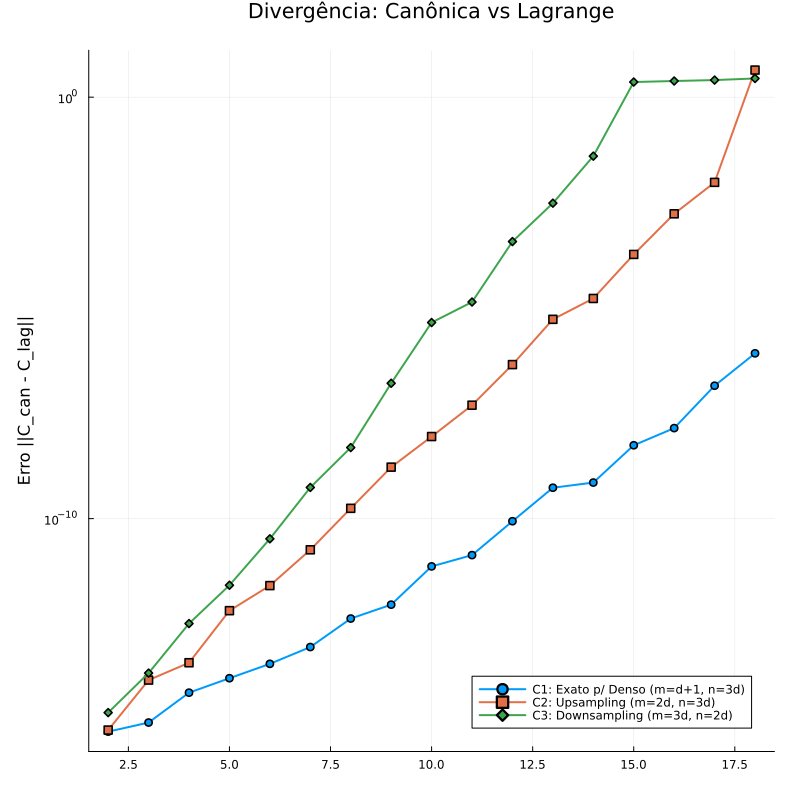

In [37]:
function calcular_composta(m, n, d)
    X = range(-1.0, 1.0, length=m)
    Y = range(-1.0, 1.0, length=n)

    # Via Canônica
    V_X = matrix_vandermonde(X, d)
    V_Y = matrix_vandermonde(Y, d)
    C_can = V_Y * pinv(V_X)

    # Via Lagrange
    X_base = X[1:d+1] 
    A_X = matrix_lagrange(X, d)
    A_Y = matrix_lagrange_cruzada(Y, X_base, d)
    C_lag = A_Y * pinv(A_X)

    # Métricas
    erro = norm(C_can - C_lag)
    cond_lag = cond(C_lag)

    return erro, cond_lag
end

function plot_analise_composta(d_max=18)
    degrees = 2:d_max
    
    # Listas para armazenar os resultados de 3 cenários diferentes
    erro_c1 = Float64[]
    erro_c2 = Float64[]
    erro_c3 = Float64[]
    
    for d in degrees
        # CENÁRIO 1: Interpolação Exata -> Upsampling (m = d+1, n = 3d)
        e1, c1 = calcular_composta(d + 1, 3 * d, d)
        push!(erro_c1, e1)
        
        # CENÁRIO 2: Mínimos Quadrados -> Upsampling (m = 2d, n = 3d)
        e2, c2 = calcular_composta(2 * d, 3 * d, d)
        push!(erro_c2, e2)
        
        # CENÁRIO 3: Mínimos Quadrados -> Downsampling (m = 3d, n = 2d)
        e3, c3 = calcular_composta(3 * d, 2 * d, d)
        push!(erro_c3, e3)
    end

    p3 = plot(title="Divergência: Canônica vs Lagrange",
              ylabel="Erro ||C_can - C_lag||",
              yscale=:log10, legend=:bottomright, grid=true,
              margin=4Plots.mm)
    plot!(p3, degrees, erro_c1, label="C1: Exato p/ Denso (m=d+1, n=3d)", lw=2, marker=:circle)
    plot!(p3, degrees, erro_c2, label="C2: Upsampling (m=2d, n=3d)", lw=2, marker=:square)
    plot!(p3, degrees, erro_c3, label="C3: Downsampling (m=3d, n=2d)", lw=2, marker=:diamond)
    

    
    # Juntando os dois gráficos em um painel (2 linhas, 1 coluna)
    grafico_final = plot(p3, layout=(1, 1), size=(800, 800))
    
    return grafico_final
end

# Executa a análise até o grau 18 (o suficiente para quebrar a base canônica)
plot_analise_composta(18)

## Letra (e):

Qual o condicionamento da composta $L_Y\circ R_{X,d}$? Você pode fazer $n \to \infty$ sem prejudicar o condicionamento? E $d \to\infty$?

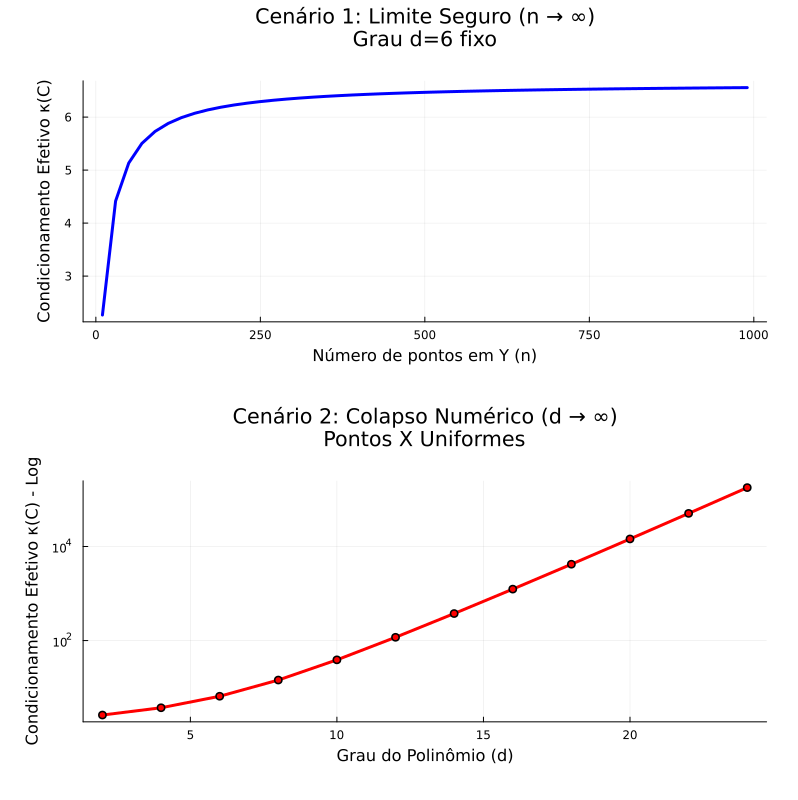

In [54]:
function visualizar_limites()
    # ---------------------------------------------------------
    # TESTE 1: O Limite Seguro (n -> infinito)
    # ---------------------------------------------------------
    d_fixo = 6
    
    # AGORA É SEGURO MUDAR ISSO: Você pode testar m_fixo = 2 * d_fixo se quiser!
    m_fixo = d_fixo + 1 
    
    X_fixo = range(-1.0, 1.0, length=m_fixo)
    X_base_fixo = X_fixo[1:d_fixo+1]
    
    A_X_fixo = matrix_lagrange(X_fixo, d_fixo)
    inv_A_X = pinv(A_X_fixo)

    n_vals = 10:20:1000 
    cond_n = Float64[]

    for n in n_vals
        Y = range(-1.0, 1.0, length=n)
        A_Y = matrix_lagrange_cruzada(Y, X_base_fixo, d_fixo)
        
        C = A_Y * inv_A_X
        
        # --- A CORREÇÃO UNIVERSAL ---
        sv_C = svdvals(C)
        cond_efetivo = sv_C[1] / sv_C[d_fixo + 1] 
        push!(cond_n, cond_efetivo)
    end

    p1 = plot(n_vals, cond_n,
              title="Cenário 1: Limite Seguro (n → ∞)\nGrau d=6 fixo",
              xlabel="Número de pontos em Y (n)",
              ylabel="Condicionamento Efetivo κ(C)",
              lw=3, color=:blue, legend=false,
              grid=true, margin=6Plots.mm)

    # ---------------------------------------------------------
    # TESTE 2: O Limite Catastrófico (d -> infinito)
    # ---------------------------------------------------------
    d_vals = 2:2:24 
    cond_d = Float64[]

    n_sensores = 1000 
    Y_sensores = range(-1.0, 1.0, length=n_sensores)

    for d in d_vals
        m = d + 1 # Pode mudar para m = 2*d com segurança também!
        X = range(-1.0, 1.0, length=m)
        X_base = X[1:d+1]

        A_X = matrix_lagrange(X, d)
        A_Y = matrix_lagrange_cruzada(Y_sensores, X_base, d)
        
        C = A_Y * pinv(A_X)
        
        # --- A CORREÇÃO UNIVERSAL ---
        sv_C = svdvals(C)
        cond_efetivo = sv_C[1] / sv_C[d + 1]
        push!(cond_d, cond_efetivo)
    end

    p2 = plot(d_vals, cond_d,
              title="Cenário 2: Colapso Numérico (d → ∞)\nPontos X Uniformes",
              xlabel="Grau do Polinômio (d)",
              ylabel="Condicionamento Efetivo κ(C) - Log",
              yscale=:log10, 
              lw=3, color=:red, marker=:circle, legend=false,
              grid=true, margin=6Plots.mm)

    grafico_final = plot(p1, p2, layout=(2, 1), size=(800, 800))
    
    display(grafico_final)
    return grafico_final
end

visualizar_limites();

## Letra (f):

Refaça os exercícios (c) e (d) substituindo $X$ pelo conjunto dos "pontos de Chebyshev" $x_i = \cos\left(\frac {2i - i}{2m}\pi\right)$.

In [55]:
function gerar_chebyshev_para_sua_funcao(m, d)
    # 1. Gera todos os m pontos de Chebyshev ordenados
    X_m = sort([cos(pi * (2i - 1) / (2 * m)) for i in 1:m])
    
    # 2. Pega índices igualmente espaçados para garantir uma boa base
    idx_base = round.(Int, range(1, m, length=d+1))
    
    # 3. Separa a base escolhida do restante dos pontos
    X_base = X_m[idx_base]
    X_resto = deleteat!(copy(X_m), idx_base)
    
    # 4. Coloca a base na frente (para a sua função ler perfeitamente) e o resto depois
    return vcat(X_base, X_resto)
end

# ==========================================
# 3. COMPARAÇÃO (Questão 3f)
# ==========================================
function executar_questao_3f()
    m = 30
    n = 45
    d = 16
    
    # Vetor X com m nós de Chebyshev (reordenado para a sua função)
    X = gerar_chebyshev_para_sua_funcao(m, d)
    
    # Vetor Y com pontos uniformes (sensores)
    Y = range(-1.0, 1.0, length=n)
    
    # A base que a sua matriz vai extrair internamente
    X_base = X[1:d+1] 
    
    println("============================================================")
    @printf("QUESTÃO 3F: Chebyshev | m = %d | n = %d | Grau d = %d\n", m, n, d)
    println("============================================================")

    # Via Canônica
    V_X = matrix_vandermonde(X, d)
    V_Y = matrix_vandermonde(Y, d)
    C_can = V_Y * pinv(V_X) 
    sv_can = svdvals(C_can)

    # Via Lagrange (Usando SUAS funções)
    A_X = matrix_lagrange(X, d)
    A_Y = matrix_lagrange_cruzada(Y, X_base, d)
    C_lag = A_Y * pinv(A_X)
    sv_lag = svdvals(C_lag)

    println("Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa")
    println("-----------------------------------------------------------------")
    for k in 1:(d+1)
        if k <= 3 || k >= d - 1
            diff_rel = abs(sv_can[k] - sv_lag[k]) / (abs(sv_lag[k]) + 1e-16)
            @printf("  %2d   | %.8e | %.8e |  %.2e\n", k, sv_can[k], sv_lag[k], diff_rel)
        elseif k == 4
            println("  ...  | ...                | ...                |  ...")
        end
    end
    
    # O condicionamento real é a razão entre o primeiro e o último valor singular VÁLIDO (índice d+1)
    
    @printf("=> Norma ||C_can - C_lag||:           %.2e\n", norm(C_can - C_lag))
end

executar_questao_3f()

QUESTÃO 3F: Chebyshev | m = 30 | n = 45 | Grau d = 16
Índice | σ (Canônica)       | σ (Lagrange)       | Dif. Relativa
-----------------------------------------------------------------
   1   | 1.51490222e+00 | 1.51490222e+00 |  8.17e-13
   2   | 1.50463372e+00 | 1.50463372e+00 |  2.32e-13
   3   | 1.49134848e+00 | 1.49134848e+00 |  1.31e-12
  ...  | ...                | ...                |  ...
  15   | 9.48735289e-01 | 9.48735289e-01 |  1.87e-15
  16   | 6.09612000e-01 | 6.09612000e-01 |  9.00e-13
  17   | 5.53222171e-01 | 5.53222171e-01 |  1.18e-12
=> Norma ||C_can - C_lag||:           5.95e-11
